# Q4 - Sarcasm Explanation & Error Analysis
Nikolas Ziartis
- **Source model:** TinyLlama-1.1B LoRA adapters (best per-variety, from Q2.3)
- **Error data:** `error_analysis.csv` generated by Member 4's Section C
- **Pipeline:** Extract 10 errors -> Explain 4 -> Build zero-shot and few-shot prompts -> Test remaining 6 -> Before/after analysis

In [1]:
import pandas as pd
import numpy as np
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
# Load error analysis CSV from Member 4's LoRA notebook (Section C)
errors_df = pd.read_csv("error_analysis.csv")
print(f"Total errors: {len(errors_df)}")

# Filter to in-distribution only (adapter tested on same variety it was trained on)
indist = errors_df[errors_df['adapter_variety'] == errors_df['test_variety']].copy()
print(f"In-distribution errors: {len(indist)}")
print()
print(indist.groupby(['adapter_variety', 'error_type']).size().unstack(fill_value=0))

Total errors: 1330
In-distribution errors: 283

error_type       False Negative  False Positive
adapter_variety                                
en-AU                        52             109
en-IN                        46              14
en-UK                        25              37


## Step 1 - Select 10 Erroneous Predictions

Diverse set: mix of False Negatives and False Positives, all three varieties.

In [ ]:
# Hand-picked 10 examples - pattern-matched for tight few-shot transfer
# The 4 explained examples (2, 3, 5, 7) teach 4 specific patterns:
#   - Ex 2: genuine positive reaction (NOT sarcastic despite positive word)
#   - Ex 3: positive word + negative reality (verbal irony - sarcastic)
#   - Ex 5: mock enthusiasm "so much to choose from" (sarcastic)
#   - Ex 7: dramatic but sincere complaint (NOT sarcastic)
# Balanced 2 Sarcastic + 2 Non-Sarcastic examples to prevent label bias.
selected_texts = [
    # 1: en-UK FN (Sarcastic) - positive word "great" + negative reality 
    "Its great we cant defend ourselves. I really hope all four of them are all okay though.",
    # 2: en-UK FP (Non-Sarcastic) - genuine positive reaction "Brilliant" (EXPLAINED)
    "I laughed out loud at that. Brilliant",
    # 3: en-AU FN (Sarcastic) - positive word + negative reality (EXPLAINED)
    "It's great, barely any customers and the cinemas are always empty.",
    # 4: en-AU FN (Sarcastic) - mock enthusiasm "Just love to see it" 
    "Rich families that own houses getting a free reno. Just love to see it.",
    # 5: en-IN FN (Sarcastic) - mock enthusiasm "so much to choose from" (EXPLAINED)
    "Will we die of heat, dehydration or asphyxiation? So much to choose from!",
    # 6: en-AU FN (Sarcastic) - mock praise "genius and mind reader WOW" 
    "so you're a genius and a mind reader WOW.",
    # 7: en-UK FP (Non-Sarcastic) - dramatic but sincere complaint (EXPLAINED)
    "The internet has ruined everything.",
    # 8: en-UK FP (Non-Sarcastic) - dramatic sincere fear 
    "Dystopian nightmare pod.",
    # 9: en-UK FP (Non-Sarcastic) - dramatic sincere complaint 
    "Boris.... always the bumbly fumbly'doing it for the bants' attention whore.....",
    # 10: en-IN FP (Non-Sarcastic) - dramatic sincere agreement 
    "I'm with you people, DO NOT LET HIM GET AWAY",
]

# Match against the error CSV to get full metadata
selected_rows = []
for text in selected_texts:
    match = indist[indist['text'] == text]
    if len(match) == 0:
        print(f"WARNING: no match for: {text[:60]}...")
    else:
        selected_rows.append(match.iloc[0])

selected_df = pd.DataFrame(selected_rows).reset_index(drop=True)
selected_df.index = range(1, len(selected_df) + 1)
selected_df.index.name = '#'

print(f"Selected {len(selected_df)} examples:\n")
for i, row in selected_df.iterrows():
    label = "FN" if row['error_type'] == 'False Negative' else "FP"
    print(f"  [{i:>2}] {label} | {row['adapter_variety']} | True={row['true_label']} Pred={row['predicted_label']}")
    print(f"       {row['text'][:100]}")
    print()

Selected 10 examples:

  [ 1] FN | en-UK | True=1 Pred=0
       Its great we cant defend ourselves. I really hope all four of them are all okay though.

  [ 2] FP | en-UK | True=0 Pred=1
       I laughed out loud at that. Brilliant

  [ 3] FN | en-AU | True=1 Pred=0
       It's great, barely any customers and the cinemas are always empty.

  [ 4] FN | en-AU | True=1 Pred=0
       Rich families that own houses getting a free reno. Just love to see it.

  [ 5] FN | en-IN | True=1 Pred=0
       Will we die of heat, dehydration or asphyxiation? So much to choose from!

  [ 6] FN | en-AU | True=1 Pred=0
       so you're a genius and a mind reader WOW.

  [ 7] FP | en-UK | True=0 Pred=1
       The internet has ruined everything.

  [ 8] FP | en-UK | True=0 Pred=1
       Dystopian nightmare pod.

  [ 9] FP | en-UK | True=0 Pred=1
       Boris.... always the bumbly fumbly'doing it for the bants' attention whore.....

  [10] FP | en-IN | True=0 Pred=1
       I'm with you people, DO NOT LET HIM 

In [4]:
# Display full table of 10 selected errors
display_df = selected_df[['adapter_variety', 'text', 'true_class', 'predicted_class', 'error_type']].copy()
display_df.columns = ['Variety', 'Text', 'True Label', 'Predicted', 'Error Type']
display(display_df)

,Variety,Text,True Label,Predicted,Error Type
#,,,,,
1,en-UK,Its great we cant defend ourselves. I really h...,Sarcastic,Non-Sarcastic,False Negative
2,en-UK,I laughed out loud at that. Brilliant,Non-Sarcastic,Sarcastic,False Positive
3,en-AU,"It's great, barely any customers and the cinem...",Sarcastic,Non-Sarcastic,False Negative
4,en-AU,Rich families that own houses getting a free r...,Sarcastic,Non-Sarcastic,False Negative
5,en-IN,"Will we die of heat, dehydration or asphyxiati...",Sarcastic,Non-Sarcastic,False Negative
6,en-AU,so you're a genius and a mind reader WOW.,Sarcastic,Non-Sarcastic,False Negative
7,en-UK,The internet has ruined everything.,Non-Sarcastic,Sarcastic,False Positive
8,en-UK,Dystopian nightmare pod.,Non-Sarcastic,Sarcastic,False Positive
9,en-UK,Boris.... always the bumbly fumbly'doing it fo...,Non-Sarcastic,Sarcastic,False Positive


## Step 2 - Linguistically Grounded Explanations (4 examples)

Examples **2, 3, 5, 7** selected - covering all three varieties and both error types.

In [ ]:
# EXPLANATIONS
# Order: 3 (Sarc) -> 5 (Sarc) -> 2 (Non-Sarc) -> 7 (Non-Sarc)
# Last two examples are Non-Sarcastic to counteract the model's strong bias
# toward predicting "Sarcastic" (recency-bias mitigation).

explanations = {
    3: {
        "text": selected_df.loc[3, 'text'],
        "variety": selected_df.loc[3, 'adapter_variety'],
        "true_label": "Sarcastic",
        "explanation": (
            "This is sarcastic because the word 'great' doesn't match with the rest of the "
            "sentence. No customers and empty cinemas is bad for the cinema's business, "
            "not great, so the speaker clearly means the opposite. The model "
            "probably got confused because the word 'great' has a strong positive meaning, and "
            "the rest of the sentence just describes a fact instead of using "
            "negative words, so nothing shows the negative meaning for it."
        ),
    },
    5: {
        "text": selected_df.loc[5, 'text'],
        "variety": selected_df.loc[5, 'adapter_variety'],
        "true_label": "Sarcastic",
        "explanation": (
            "This is sarcastic because the speaker uses a happy, excited phrase at the end of the sentence: "
            "'So much to choose from!' about 3 ways of dying. That "
            "phrase is normally used for nice things like food or holidays, not "
            "for picking how you die. The joke is that the happy ending doesn't fit the sad list. The model likely saw the excited phrase "
            "as positive and ignored that the choices themselves are all deadly."
        ),
    },
    2: {
        "text": selected_df.loc[2, 'text'],
        "variety": selected_df.loc[2, 'adapter_variety'],
        "true_label": "Non-Sarcastic",
        "explanation": (
            "This is not sarcastic, the speaker really liked what they saw. "
            "'Laughed out loud' shows they found it funny, and 'Brilliant' "
            "here just means 'very good'. The words are positive and the feeling is positive too,"
            " so they match and there is no hidden "
            "opposite meaning. The model probably picked sarcastic because 'Brilliant' "
            "is a strong positive word and people sometimes say it in an ironic way, but a positive word on its own is not enough for sarcasm, the rest "
            "of the sentence has to say the opposite, and here it doesn't."
        ),
    },
    7: {
        "text": selected_df.loc[7, 'text'],
        "variety": selected_df.loc[7, 'adapter_variety'],
        "true_label": "Non-Sarcastic",
        "explanation": (
            "This is not sarcastic, it is a real complaint. The speaker is "
            "being dramatic, but actually means what they say: they really do think the "
            "internet has made things worse. The words are negative and also the feeling is negative too, therefore there is no opposite meaning. "
            "The model probably guessed sarcasm because words like 'everything' "
            "and 'ruined' sound dramatic, but being dramatic is not the same as being "
            "sarcastic. Sarcasm needs the real meaning to be the opposite of the "
            "words, and here it isn't."
        ),
    },
}

# Display for verification
for idx, exp in explanations.items():
    print(f"Example {idx} [{exp['variety']}] - {exp['true_label']}")
    print(f"  Text: {exp['text']}")
    print(f"  Explanation: {exp['explanation'][:100]}...")
    print()

Example 3 [en-AU] — Sarcastic
  Text: It's great, barely any customers and the cinemas are always empty.
  Explanation: This is sarcastic because the word 'great' doesn't match with the rest of the sentence. No customers...

Example 5 [en-IN] — Sarcastic
  Text: Will we die of heat, dehydration or asphyxiation? So much to choose from!
  Explanation: This is sarcastic because the speaker uses a happy, excited phrase at the end of the sentence: 'So m...

Example 2 [en-UK] — Non-Sarcastic
  Text: I laughed out loud at that. Brilliant
  Explanation: This is not sarcastic, the speaker really liked what they saw. 'Laughed out loud' shows they found i...

Example 7 [en-UK] — Non-Sarcastic
  Text: The internet has ruined everything.
  Explanation: This is not sarcastic, it is a real complaint. The speaker is being dramatic, but actually means wha...



## Step 3 - Build Zero-Shot and Few-Shot Prompts

We test three conditions on the 6 remaining examples:
1. **Original model** - the LoRA adapter prediction (already wrong for all 6)
2. **Zero-shot** - LLM with task description only, no examples
3. **Few-shot (4-shot)** - LLM with 4 explained examples from Step 2

This progression shows whether providing examples and explanations improves sarcasm detection.

In [ ]:
# Chain-of-thought prompts using the optimal CoT trigger phrase
# from Kojima et al. (2022): "Let's work this out in a step by step way
# to be sure we have the right answer." (82% accuracy in their study,
# vs 78.7% for "Let's think step by step.")
# Combined with prefix priming "This text is" to prevent example continuation.

def build_zeroshot_prompt(test_text, test_variety):
    prompt = (
        "You are a sarcasm detection system for varieties of English "
        "(British, Australian, Indian).\n"
        "Determine whether the following text is sarcastic or not.\n\n"
        f"Input: \"{test_text}\"\n"
        f"Dialect: {test_variety}\n\n"
        "Let's work this out in a step by step way to be sure we have the right answer. "
        "This text is "
    )
    return prompt


def build_fewshot_prompt(explanations_dict, test_text, test_variety):
    prompt = (
        "You are a sarcasm detection system for varieties of English "
        "(British, Australian, Indian).\n"
        "Below are examples showing how to reason about sarcasm step by step "
        "before reaching a final answer.\n\n"
    )

    for idx, exp in explanations_dict.items():
        prompt += f"Example {idx}:\n"
        prompt += f"Text: \"{exp['text']}\"\n"
        prompt += f"Variety: {exp['variety']}\n"
        prompt += f"Reasoning: {exp['explanation'].strip()}\n"
        prompt += f"Answer: {exp['true_label']}\n\n"

    prompt += (
        "=== END OF EXAMPLES ===\n\n"
        "Now classify this NEW text. Do not generate new examples - analyse "
        "only the input below.\n\n"
        f"Input: \"{test_text}\"\n"
        f"Dialect: {test_variety}\n\n"
        "Let's work this out in a step by step way to be sure we have the right answer. "
        "This text is "
    )
    return prompt


test_indices = [i for i in selected_df.index if i not in explanations]
print(f"4 explained examples (few-shot): {list(explanations.keys())}")
print(f"6 test examples: {test_indices}")

4 explained examples (few-shot): [3, 5, 2, 7]
6 test examples: [1, 4, 6, 8, 9, 10]


In [ ]:
# Preview both prompts for the first test example
first_test = selected_df.loc[test_indices[0]]

print("-- ZERO-SHOT PROMPT PREVIEW --")
print(build_zeroshot_prompt(first_test['text'], first_test['adapter_variety']))
print()
print("-- FEW-SHOT PROMPT PREVIEW --")
print(build_fewshot_prompt(explanations, first_test['text'], first_test['adapter_variety']))

── ZERO-SHOT PROMPT PREVIEW ──
You are a sarcasm detection system for varieties of English (British, Australian, Indian).
Determine whether the following text is sarcastic or not.

Input: "Its great we cant defend ourselves. I really hope all four of them are all okay though."
Dialect: en-UK

Let's work this out in a step by step way to be sure we have the right answer. This text is 

── FEW-SHOT PROMPT PREVIEW ──
You are a sarcasm detection system for varieties of English (British, Australian, Indian).
Below are examples showing how to reason about sarcasm step by step before reaching a final answer.

Example 3:
Text: "It's great, barely any customers and the cinemas are always empty."
Variety: en-AU
Reasoning: This is sarcastic because the word 'great' doesn't match with the rest of the sentence. No customers and empty cinemas is bad for the cinema's business, not great, so the speaker clearly means the opposite. The model probably got confused because the word 'great' has a strong p

In [8]:
# Load TinyLlama in generative mode for prompting
# We use the base chat model (no LoRA adapter) for zero-shot and few-shot
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print(f"Loading {MODEL_NAME} for prompting...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
gen_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

gen_model.eval()
print("✓ Model loaded")

Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0 for prompting...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✓ Model loaded


In [ ]:
def run_prompt(prompt, tokenizer, model, max_new_tokens=200):
    """Run a prompt through the model and return the generated text.
    Uses greedy decoding (do_sample=False) for deterministic, reproducible
    classification - no sampling means temperature is irrelevant."""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    generated = tokenizer.decode(
        output[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    ).strip()
    return generated


def extract_prediction(generated_text):
    """Extract the final answer. Returns 'Sarcastic' or 'Non-Sarcastic'
    to match the dataset's label naming convention."""
    full_text = ("This text is " + generated_text).lower()

    # Primary: look for 'answer:' line
    if 'answer:' in full_text:
        after = full_text.split('answer:', 1)[1].strip()
        first_line = after.split('\n')[0].strip()
        if 'not sarcastic' in first_line or 'non-sarcastic' in first_line or 'not sarcasm' in first_line:
            return "Non-Sarcastic"
        if 'sarcastic' in first_line or 'sarcasm' in first_line:
            return "Sarcastic"

    # Fallback: scan for negation forms first
    has_neg = ('not sarcastic' in full_text or 'non-sarcastic' in full_text or
               'not sarcasm' in full_text or 'no sarcasm' in full_text or
               "isn\'t sarcastic" in full_text or 'is not sarcastic' in full_text)

    if has_neg:
        last_neg = max(full_text.rfind('not sarcastic'), full_text.rfind('non-sarcastic'),
                       full_text.rfind('not sarcasm'), full_text.rfind('no sarcasm'))
        last_sarcasm = full_text.rfind('sarcasm')
        last_sarcastic = full_text.rfind('sarcastic')
        last_pos = max(last_sarcasm, last_sarcastic)

        if last_pos <= last_neg + 4:
            return "Non-Sarcastic"
        else:
            return "Sarcastic"

    if 'sarcastic' in full_text or 'sarcasm' in full_text:
        return "Sarcastic"

    return f"Unclear: {generated_text[:50]}"

print("✓ Inference functions defined")

✓ Inference functions defined


In [10]:
# Run ZERO-SHOT prompting on the 6 test examples
print("Running zero-shot prompts on 6 test examples...\n")

zeroshot_results = []
for idx in test_indices:
    row = selected_df.loc[idx]
    prompt = build_zeroshot_prompt(row['text'], row['adapter_variety'])
    generated = run_prompt(prompt, tokenizer, gen_model)
    pred = extract_prediction(generated)

    zeroshot_results.append({
        'index': idx,
        'variety': row['adapter_variety'],
        'text': row['text'],
        'true_label': row['true_class'],
        'original_pred': row['predicted_class'],
        'zeroshot_pred': pred,
        'zeroshot_raw': generated[:200],
    })

    print(f"[{idx}] {row['adapter_variety']} | True={row['true_class']}")
    print(f"     Original:  {row['predicted_class']}")
    print(f"     Zero-shot: {pred}")
    print(f"     Raw: {generated[:120]}")
    print()

Running zero-shot prompts on 6 test examples...

[1] en-UK | True=Sarcastic
     Original:  Non-Sarcastic
     Zero-shot: Sarcastic
     Raw: 100% sarcastic.

1. The first sentence is a direct quote from the text.
2. The second sentence is a direct quote from th

[4] en-AU | True=Sarcastic
     Original:  Non-Sarcastic
     Zero-shot: Sarcastic
     Raw: 100% sarcastic.

1. The first sentence is a direct quote from the text material.
2. The second sentence is a direct quot

[6] en-AU | True=Sarcastic
     Original:  Non-Sarcastic
     Zero-shot: Sarcastic
     Raw: 100% sarcastic.

1. The first word is "so" which is a negative word.
2. The second word is "you're" which is a positive 

[8] en-UK | True=Non-Sarcastic
     Original:  Sarcastic
     Zero-shot: Sarcastic
     Raw: 100% sarcastic.

1. The text is in the past tense.
2. The text is about a pod.
3. The text is about a nightmare.
4. The 

[9] en-UK | True=Non-Sarcastic
     Original:  Sarcastic
     Zero-shot: Sarcastic
     Raw

In [11]:
# Run FEW-SHOT (4-shot) prompting on the same 6 test examples
print("Running few-shot prompts on 6 test examples...\n")

fewshot_results = []
for idx in test_indices:
    row = selected_df.loc[idx]
    prompt = build_fewshot_prompt(explanations, row['text'], row['adapter_variety'])
    generated = run_prompt(prompt, tokenizer, gen_model)
    pred = extract_prediction(generated)

    fewshot_results.append({
        'index': idx,
        'fewshot_pred': pred,
        'fewshot_raw': generated[:200],
    })

    print(f"[{idx}] {row['adapter_variety']} | True={row['true_class']}")
    print(f"     Original:  {row['predicted_class']}")
    print(f"     Zero-shot: {zeroshot_results[test_indices.index(idx)]['zeroshot_pred']}")
    print(f"     Few-shot:  {pred}")
    print(f"     Raw: {generated[:120]}")
    print()

Running few-shot prompts on 6 test examples...

[1] en-UK | True=Sarcastic
     Original:  Non-Sarcastic
     Zero-shot: Sarcastic
     Few-shot:  Sarcastic
     Raw: 100% sarcasm.

1. First, we need to determine if the text is sarcastic or not.

2. The text is sarcastic because the spe

[4] en-AU | True=Sarcastic
     Original:  Non-Sarcastic
     Zero-shot: Sarcastic
     Few-shot:  Sarcastic
     Raw: 100% sarcasm.

1. First, we need to determine if the text is sarcastic or not.

2. The text is sarcastic because the spe

[6] en-AU | True=Sarcastic
     Original:  Non-Sarcastic
     Zero-shot: Sarcastic
     Few-shot:  Sarcastic
     Raw: 100% sarcasm.

1. First, we need to determine if the speaker is using a positive word or a negative word. In this case, 

[8] en-UK | True=Non-Sarcastic
     Original:  Sarcastic
     Zero-shot: Sarcastic
     Few-shot:  Non-Sarcastic
     Raw: 100% sarcasm.

1. First, we need to determine the dialect. In this case, it's en-UK.
2. Next, we need to d

## Step 4 - Before-and-After Comparison

Three-way comparison: Original LoRA adapter -> Zero-shot prompting -> Few-shot (4-shot) prompting.

In [ ]:
# Build three-way comparison table
comparison_rows = []
for i, idx in enumerate(test_indices):
    zs = zeroshot_results[i]
    fs = fewshot_results[i]
    true = zs['true_label']

    comparison_rows.append({
        '#': idx,
        'Variety': zs['variety'],
        'Text': zs['text'][:70] + '...' if len(zs['text']) > 70 else zs['text'],
        'True Label': true,
        'Original': zs['original_pred'],
        'Zero-Shot': zs['zeroshot_pred'],
        'Few-Shot': fs['fewshot_pred'],
        'Original Correct': '✓' if zs['original_pred'] == true else '✗',
        'ZS Correct': '✓' if zs['zeroshot_pred'] == true else '✗',
        'FS Correct': '✓' if fs['fewshot_pred'] == true else '✗',
    })

comp_df = pd.DataFrame(comparison_rows).set_index('#')

print("BEFORE vs AFTER - Three-Way Comparison")
print("=" * 95)
display(comp_df[['Variety', 'True Label', 'Original', 'Zero-Shot', 'Few-Shot',
                  'Original Correct', 'ZS Correct', 'FS Correct']])

# Summary
n = len(comparison_rows)
n_orig = sum(1 for r in comparison_rows if r['Original Correct'] == '✓')
n_zs = sum(1 for r in comparison_rows if r['ZS Correct'] == '✓')
n_fs = sum(1 for r in comparison_rows if r['FS Correct'] == '✓')

print(f"\nAccuracy Summary:")
print(f"  Original LoRA adapter: {n_orig}/{n} correct (all wrong by design)")
print(f"  Zero-shot prompting:   {n_zs}/{n} correct")
print(f"  Few-shot prompting:    {n_fs}/{n} correct")
print(f"  Improvement (ZS->FS):   {n_fs - n_zs:+d} examples")

BEFORE vs AFTER — Three-Way Comparison


,Variety,True Label,Original,Zero-Shot,Few-Shot,Original Correct,ZS Correct,FS Correct
#,,,,,,,,
1,en-UK,Sarcastic,Non-Sarcastic,Sarcastic,Sarcastic,✗,✓,✓
4,en-AU,Sarcastic,Non-Sarcastic,Sarcastic,Sarcastic,✗,✓,✓
6,en-AU,Sarcastic,Non-Sarcastic,Sarcastic,Sarcastic,✗,✓,✓
8,en-UK,Non-Sarcastic,Sarcastic,Sarcastic,Non-Sarcastic,✗,✗,✓
9,en-UK,Non-Sarcastic,Sarcastic,Sarcastic,Sarcastic,✗,✗,✗
10,en-IN,Non-Sarcastic,Sarcastic,Sarcastic,Sarcastic,✗,✗,✗



Accuracy Summary:
  Original LoRA adapter: 0/6 correct (all wrong by design)
  Zero-shot prompting:   3/6 correct
  Few-shot prompting:    4/6 correct
  Improvement (ZS→FS):   +1 examples


In [13]:
# Breakdown by error type
print("Breakdown by Error Type:")
print("-" * 60)
for etype in ['False Negative', 'False Positive']:
    indices_et = [i for i, idx in enumerate(test_indices)
                  if selected_df.loc[idx, 'error_type'] == etype]
    if not indices_et:
        continue
    n_et = len(indices_et)
    zs_fixed = sum(1 for i in indices_et if comparison_rows[i]['ZS Correct'] == '✓')
    fs_fixed = sum(1 for i in indices_et if comparison_rows[i]['FS Correct'] == '✓')
    print(f"  {etype} ({n_et} examples):")
    print(f"    Zero-shot fixed: {zs_fixed}/{n_et}")
    print(f"    Few-shot fixed:  {fs_fixed}/{n_et}")
    print()

# Breakdown by variety
print("Breakdown by Variety:")
print("-" * 60)
for variety in ['en-AU', 'en-UK', 'en-IN']:
    indices_v = [i for i, idx in enumerate(test_indices)
                 if zeroshot_results[i]['variety'] == variety]
    if not indices_v:
        continue
    n_v = len(indices_v)
    zs_fixed = sum(1 for i in indices_v if comparison_rows[i]['ZS Correct'] == '✓')
    fs_fixed = sum(1 for i in indices_v if comparison_rows[i]['FS Correct'] == '✓')
    print(f"  {variety} ({n_v} examples):")
    print(f"    Zero-shot fixed: {zs_fixed}/{n_v}")
    print(f"    Few-shot fixed:  {fs_fixed}/{n_v}")
    print()

Breakdown by Error Type:
------------------------------------------------------------
  False Negative (3 examples):
    Zero-shot fixed: 3/3
    Few-shot fixed:  3/3

  False Positive (3 examples):
    Zero-shot fixed: 0/3
    Few-shot fixed:  1/3

Breakdown by Variety:
------------------------------------------------------------
  en-AU (2 examples):
    Zero-shot fixed: 2/2
    Few-shot fixed:  2/2

  en-UK (3 examples):
    Zero-shot fixed: 1/3
    Few-shot fixed:  2/3

  en-IN (1 examples):
    Zero-shot fixed: 0/1
    Few-shot fixed:  0/1



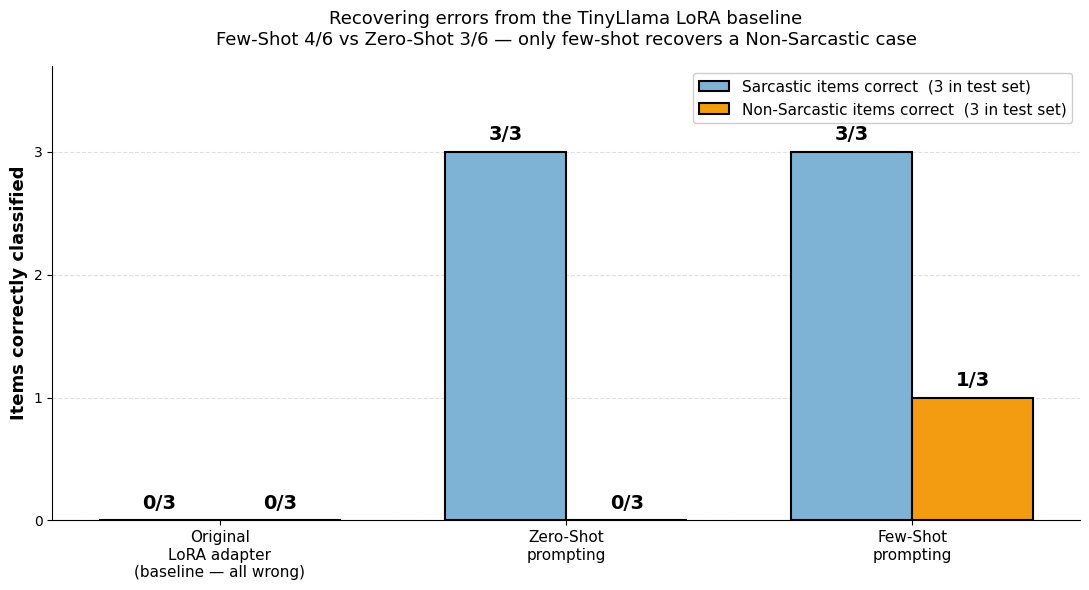


✓ Saved as q4_results.png


In [ ]:
# Visualisation: comparison of baseline LoRA, zero-shot, and few-shot prompting
import matplotlib.pyplot as plt
import numpy as np

def count(method_col, error_type):
    return sum(1 for i, idx in enumerate(test_indices)
               if selected_df.loc[idx, 'error_type'] == error_type
               and comparison_rows[i][method_col] == '✓')

orig_sarc, orig_nonsarc = 0, 0
zs_sarc = count('ZS Correct', 'False Negative')
zs_nonsarc = count('ZS Correct', 'False Positive')
fs_sarc = count('FS Correct', 'False Negative')
fs_nonsarc = count('FS Correct', 'False Positive')

methods = ['Original\nLoRA adapter\n(baseline - all wrong)', 'Zero-Shot\nprompting', 'Few-Shot\nprompting']
sarc_scores = [orig_sarc, zs_sarc, fs_sarc]
nonsarc_scores = [orig_nonsarc, zs_nonsarc, fs_nonsarc]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, sarc_scores, width,
                label='Sarcastic items correct  (3 in test set)',
                color='#7FB3D5', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, nonsarc_scores, width,
                label='Non-Sarcastic items correct  (3 in test set)',
                color='#F39C12', edgecolor='black', linewidth=1.5)

for bars, scores in [(bars1, sarc_scores), (bars2, nonsarc_scores)]:
    for bar, s in zip(bars, scores):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.06,
                f'{s}/3', ha='center', va='bottom',
                fontsize=14, fontweight='bold')

ax.set_ylabel('Items correctly classified', fontsize=13, fontweight='bold')
ax.set_title('Recovering errors from the TinyLlama LoRA baseline\n'
             'Few-Shot 4/6 vs Zero-Shot 3/6 - only few-shot recovers a Non-Sarcastic case',
             fontsize=13, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylim(0, 3.7)
ax.set_yticks([0, 1, 2, 3])
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('q4_results.png', dpi=200, bbox_inches='tight')
plt.show()
print("\n✓ Saved as q4_results.png")

In [ ]:
# Full prompt templates and raw responses for the report
print("=" * 80)
print("ZERO-SHOT PROMPT TEMPLATE")
print("=" * 80)
print(build_zeroshot_prompt("[TEXT]", "[VARIETY]"))

print()
print("=" * 80)
print("FEW-SHOT PROMPT TEMPLATE")
print("=" * 80)
print(build_fewshot_prompt(explanations, "[TEXT]", "[VARIETY]"))

print()
print("=" * 80)
print("RAW MODEL RESPONSES - ZERO-SHOT")
print("=" * 80)
for r in zeroshot_results:
    print(f"\n[{r['index']}] {r['variety']} | True: {r['true_label']}")
    print(f"  Response: {r['zeroshot_raw']}")

print()
print("=" * 80)
print("RAW MODEL RESPONSES - FEW-SHOT")
print("=" * 80)
for r in fewshot_results:
    idx = r['index']
    true = zeroshot_results[test_indices.index(idx)]['true_label']
    variety = zeroshot_results[test_indices.index(idx)]['variety']
    print(f"\n[{idx}] {variety} | True: {true}")
    print(f"  Response: {r['fewshot_raw']}")

ZERO-SHOT PROMPT TEMPLATE
You are a sarcasm detection system for varieties of English (British, Australian, Indian).
Determine whether the following text is sarcastic or not.

Input: "[TEXT]"
Dialect: [VARIETY]

Let's work this out in a step by step way to be sure we have the right answer. This text is 

FEW-SHOT PROMPT TEMPLATE
You are a sarcasm detection system for varieties of English (British, Australian, Indian).
Below are examples showing how to reason about sarcasm step by step before reaching a final answer.

Example 3:
Text: "It's great, barely any customers and the cinemas are always empty."
Variety: en-AU
Reasoning: This is sarcastic because the word 'great' doesn't match with the rest of the sentence. No customers and empty cinemas is bad for the cinema's business, not great, so the speaker clearly means the opposite. The model probably got confused because the word 'great' has a strong positive meaning, and the rest of the sentence just describes a fact instead of using ne